In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

base_dir = os.path.dirname(os.path.dirname(os.getcwd()))
data_dir = os.path.join(base_dir, 'data', 'processed_data', 'House2_full.csv')
train_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.csv')
test_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.csv')
train_h5_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.h5')
test_h5_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.h5')
sys.path.append(base_dir)
train_npy_dir = os.path.join(base_dir, 'data', 'train', 'train_house2.npy')
test_npy_dir = os.path.join(base_dir, 'data', 'test', 'test_house2.npy')
test_visualize_dir = os.path.join(base_dir, 'data', 'test', 'test_house2_for_visualize.npy')

from src.tools.window_shifter import WindowShifter
from src.metrics.energy_base_metrics import MAE, NEP, Precision_energy_based, Recall_energy_based, F1_energy_based

In [3]:
import numpy as np
import torch
from torch.utils.data import Dataset

class NILMDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.transform = transform
        npy_dir = data_dir.replace('.h5', '.npy')
        self.data_matrix = np.load(data_dir, mmap_mode='r')
        self.total_lines = self.data_matrix.shape[0]

    def __len__(self):
        return self.total_lines

    def __getitem__(self, idx):
        row = self.data_matrix[idx] 
        data = torch.tensor(row[:-9], dtype=torch.float32)
        label = torch.tensor(row[-9:], dtype=torch.float32)
        if self.transform:
            data = self.transform(data)
        data = data.unsqueeze(dim = 0)
        return data, label


In [4]:
train_set = np.load(train_npy_dir)
train_target = train_set[:,-9:]

In [5]:
train_target[:,8].shape

(4586581,)

In [4]:
train_dataset = NILMDataset(train_npy_dir)
test_dataset = NILMDataset(test_npy_dir)
visualize_dataset = NILMDataset(test_visualize_dir)

In [5]:
batch_size = 1024
train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = True, num_workers = 0)
visualize_loader = DataLoader(dataset = visualize_dataset, batch_size = batch_size, shuffle = False, num_workers = 0)

# Architecture: Encoder ###
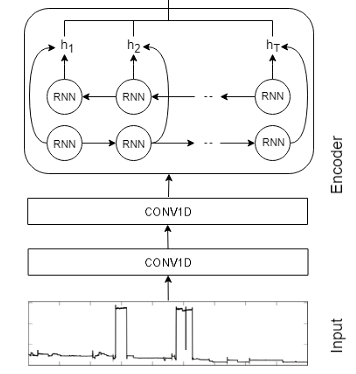

# Attention + Decoder ###
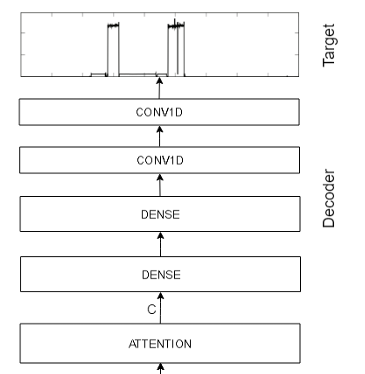

# Chú ý ###
Trong paper đang là kiến trúc s2s nhưng kiến trúc này có vấn đề chính là nó hoạt động giống nlp, yêu cầu 1 chuỗi đầu vào và đưa ra 1 chuỗi đầu ra vấn đề là nếu như có 2 chuỗi overlap với nhau thì kết quả công suất dự đoán của đoạn overlap chưa chắc giống nhau?. Vì thế nên biến đổi kiến trúc của phần decoder đi bằng cách bỏ đi 2 cái conv1d. Sau khi lấy được c từ lớp attention chỉ cần thêm 1 hoặc 2 lớp dense để lấy ra 1 output duy nhất

# Chú ý ###
Vì lstm yêu cầu đầu vào theo các bước thời gian nên cần shape là batch, length, channels, tưởng tượng mỗi bước thời gian là 1 điểm dữ liệu (có tất cả channels lớp, 1 điểm dữ liệu là xiên tất cả channels lớp đó)

# Cấu tạo của Attention ###
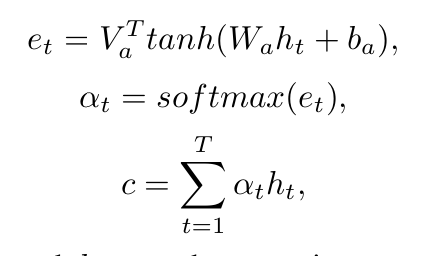

In [6]:
class S2PwAModel(nn.Module):
    def __init__(self, window_length = 300, in_channels = 1, filter_nums = 32, kernel_size = 3, hidden_dim = 64):
        super().__init__()
        self.window_length = window_length

        # Encoder
        self.conv1 = nn.Conv1d(in_channels, out_channels = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels = 32, out_channels  = filter_nums, kernel_size = kernel_size, padding = kernel_size//2)
        self.bilstm = nn.LSTM(input_size = 32, hidden_size = hidden_dim, batch_first = True, bidirectional = True)
        bilstm_out_dim = hidden_dim * 2 # concat 2 vector của hidden state theo 2 chiều

        # Attention
        self.v_a = nn.Linear(hidden_dim, 1, bias = False)
        self.att_dense = nn.Linear(bilstm_out_dim, hidden_dim)
        self.att_softmax = nn.Softmax(dim = 1)
        
        # thay đổi kiến trúc cũ
        # đầu ra của attention là batch, bilstm_out_dim
        self.fc1 = nn.Linear(bilstm_out_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64,1)
    
    def forward(self, x):
        # x sau khi lấy ra từ dataloader đang có dạng batch, channels, length
        x = self.conv1(x)
        x = self.conv2(x)
        # lstm mong đợi đầu vào dạng batch, length, channels
        x = x.permute(0,2,1) 
        h_t, _ = self.bilstm(x) 
        # h_t có dạng batch, length, hidden_dim*2
        energy = nn.Tanh()(self.att_dense(h_t)) # batch, length, hidden_dim
        score = self.v_a(energy) # batch, length, 1 (có thể hiểu là có l hidden state mối hidden state có 1 trọng số riêng để thể hiện sự đóng góp)
        alpha_t = self.att_softmax(score) # batch, length, 1
        c = (h_t * alpha_t).sum(dim = 1) # batch, hidden_dim * 2
        x = self.fc1(c) # batch, 64
        x = self.relu(x) 
        x = self.fc2(x) # batch, 1
        return x

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Tính Mean và Std của Dataset

In [7]:
df = pd.read_csv(data_dir)
app_cols = ['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']
invalid_mask_train = df['Aggregate'] <= df[app_cols].sum(axis=1)
df.loc[invalid_mask_train, app_cols] = np.nan
df.loc[invalid_mask_train, 'Aggregate'] = np.nan
df[app_cols] = df[app_cols].ffill()
df[app_cols] = df[app_cols].fillna(0)
df['Aggregate'] = df['Aggregate'].ffill()
df['Aggregate'] = df['Aggregate'].fillna(0)
df_time_to_date = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S')
df['dom'] = df_time_to_date.dt.day

In [8]:
train = df[((df['dom']-1)//7+1)%2==0]

In [9]:
train_mean = train['Aggregate'].mean()
train_std = train['Aggregate'].std()

In [8]:
train_mean, train_std = (np.float64(494.62987145211497), np.float64(1088.939294395772))

In [9]:
def Precision_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_predict.sum(axis = 0) 
    numerator = np.minimum(y_predict, y_target).sum(axis = 0) 
    return (numerator + alpha) / (denominator + alpha)
def Recall_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)
def F1_energy_based_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    numerator = np.minimum(y_predict, y_target).sum(axis = 0)
    p_denominator = y_predict.sum(axis = 0)
    r_denominator = y_target.sum(axis = 0)
    precision = (numerator + alpha) / (p_denominator + alpha)
    recall = (numerator + alpha) / (r_denominator + alpha)
    return 2 * precision * recall / (precision + recall)
def NEP_fixed(y_predict, y_target, alpha = 1e-6):
    assert y_predict.shape[0] == y_target.shape[0], 'samples number not match'
    assert y_predict.shape[1] == y_target.shape[1], 'number of appliances not match'
    denominator = y_target.sum(axis = 0)
    numerator = np.abs(y_target - y_predict).sum(axis = 0)
    return (numerator + alpha) / (denominator + alpha)

In [10]:
model_save_dir1 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app1.pth')
model_save_dir2 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app2.pth')
model_save_dir3 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app3.pth')
model_save_dir4 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app4.pth')
model_save_dir5 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app5.pth')
model_save_dir6 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app6.pth')
model_save_dir7 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app7.pth')
model_save_dir8 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app8.pth')
model_save_dir9 = os.path.join(base_dir, 'checkpoints', 'advanced models', 's2p_app9.pth')

Đã thử qua nhiều phương pháp nhưng điểm số của 1 số thiết bị không lên nổi, khả năng là nên bổ sung thêm vào tập train từ 1 số sample ở tập test đối với các thiết bị có thời gian off nhiều

In [11]:
app = ['Fridge-Freezer', 'Washing Machine', 'Dishwasher', 'Television',
'Microwave', 'Toaster', 'Hi-Fi', 'Kettle', 'Oven Extractor Fan'
]

Tạo loss function mới để chú ý nhiều hơn vào các điểm đang bật

In [12]:
import torch
import torch.nn as nn

class WeightedMAELoss(nn.Module):
    def __init__(self, weight_factor=15.0, weight_factor_off = 1.0, threshold_watt=10.0, appliance_min=0.0, appliance_max=1.0):
        super(WeightedMAELoss, self).__init__()
        self.weight_factor = weight_factor
        self.threshold_watt = threshold_watt
        self.appliance_min = appliance_min
        self.appliance_max = appliance_max
        self.weight_factor_off = weight_factor_off

    def forward(self, pred, target_scaled):
        loss = torch.abs(pred - target_scaled)
        target_watt = target_scaled * (self.appliance_max - self.appliance_min) + self.appliance_min   # chuẩn hóa ngược để xem giá trị nguyên bản có lớn hơn 0 ko
        weights = torch.where(target_watt > self.threshold_watt, self.weight_factor, self.weight_factor_off)     # tạo ra 1 tensor cùng shape nếu tmdk thì thay bởi giá trị đầu tiên ko thì 1.0
        weighted_loss = loss * weights
        return weighted_loss.mean()

In [13]:
app_min = np.array([0., 0., 0., 0., 0., 0., 0., 0., 0.])
app_max = np.array([1639., 2555., 2480.,  512., 1242., 1024., 1536., 2939.,  384.])

In [14]:
def trainer(epochs, save_dir, app_num, device = device, lr = 1e-4, weight_factor=15.0, weight_factor_off = 1.0, threshold_watt = 15.0):
    model = S2PwAModel().to(device)
    if os.path.exists(save_dir):
        model.load_state_dict(torch.load(save_dir, weights_only=True))
    criterion = WeightedMAELoss(appliance_min = app_min[app_num - 1], appliance_max = app_max[app_num - 1], weight_factor = weight_factor, threshold_watt = threshold_watt, weight_factor_off = weight_factor_off)                   # chuyển sang dùng mae
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    min_eval_loss = np.inf
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
            data = (data - train_mean)/train_std
            target = target[:,[app_num - 1]]
            target = (target - app_min[app_num - 1])/(app_max[app_num - 1] - app_min[app_num - 1])
            data, target = data.to(device).to(torch.float), target.to(device).to(torch.float)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target) 
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss/(batch_idx + 1)
        print(f'EPOCH: {epoch+1}, average train loss: {avg_train_loss}')

        model.eval()
        eval_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data_eval, target_eval) in enumerate(tqdm(test_loader)):
                data_eval = (data_eval - train_mean)/train_std
                data_eval = data_eval.to(device)
                target_eval = target_eval[:,[app_num - 1]].to(device)
                target_eval = (target_eval - app_min[app_num - 1])/(app_max[app_num - 1] - app_min[app_num - 1])
                pred = model(data_eval)
                eval_loss += criterion(pred, target_eval).item()
            avg_eval_loss = eval_loss/(batch_idx + 1)
            if avg_eval_loss < min_eval_loss:
                min_eval_loss = avg_eval_loss
                torch.save(model.state_dict(), save_dir)
            print(f'EPOCH: {epoch+1}, average eval loss: {avg_eval_loss}')
    print(f'Done training model for appliance {app_num}')

In [15]:
def tester(save_dir, app_num, test_batch_size = -1, device = device):
    model = S2PwAModel().to(device)
    model.load_state_dict(torch.load(save_dir, weights_only=True))
    model.eval()
    pred = []
    ground_truth = []
    with torch.no_grad():
        for batch_idx, (data_eval, target_eval) in enumerate(visualize_loader):
            data_eval = (data_eval - train_mean)/train_std
            data_eval = data_eval.to(device)
            target_eval = target_eval[:,[app_num - 1]].to(device)
            ground_truth += (target_eval.detach().cpu().reshape(-1).tolist())
            pred += (model(data_eval) * (app_max[app_num - 1] - app_min[app_num - 1]) + app_min[app_num - 1]).clamp(0).detach().cpu().reshape(-1).tolist()     # cần chuẩn hóa ngược lại 
            if batch_idx == test_batch_size:
                break
    plt.figure(figsize = (16,9))
    plt.plot(ground_truth, color = 'r', label = f'ground truth of app{app_num}')
    plt.plot(pred, color = 'b', label = f'prediction of app{app_num}')
    plt.legend()
    plt.show()
    print(f'f1_energy_base: {F1_energy_based_fixed(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    print(f'mae: {MAE(np.array(pred).reshape(-1,1), np.array(ground_truth).reshape(-1,1))}')
    ANE = np.abs((np.array(pred).sum() - np.array(ground_truth).sum()))/np.array(pred).sum()
    print(f'ane: {ANE}')
    return pred, ground_truth


In [17]:
trainer(epochs = 20, save_dir = model_save_dir1, app_num = 1, lr = 5e-4, weight_factor = 1.0, weight_factor_off = 1.0, threshold_watt = 15.0)

100%|██████████| 4480/4480 [09:59<00:00,  7.48it/s]


EPOCH: 1, average train loss: 0.02115185218572151


100%|██████████| 560/560 [00:29<00:00, 19.29it/s]


EPOCH: 1, average eval loss: 0.019611942541918583


100%|██████████| 4480/4480 [06:08<00:00, 12.15it/s]


...

EPOCH: 19, average eval loss: 0.008627798981199574


100%|██████████| 4480/4480 [08:07<00:00,  9.18it/s]


EPOCH: 20, average train loss: 0.005772307844329459


100%|██████████| 560/560 [00:40<00:00, 13.99it/s]

EPOCH: 20, average eval loss: 0.00852857982473714
Done training model for appliance 1


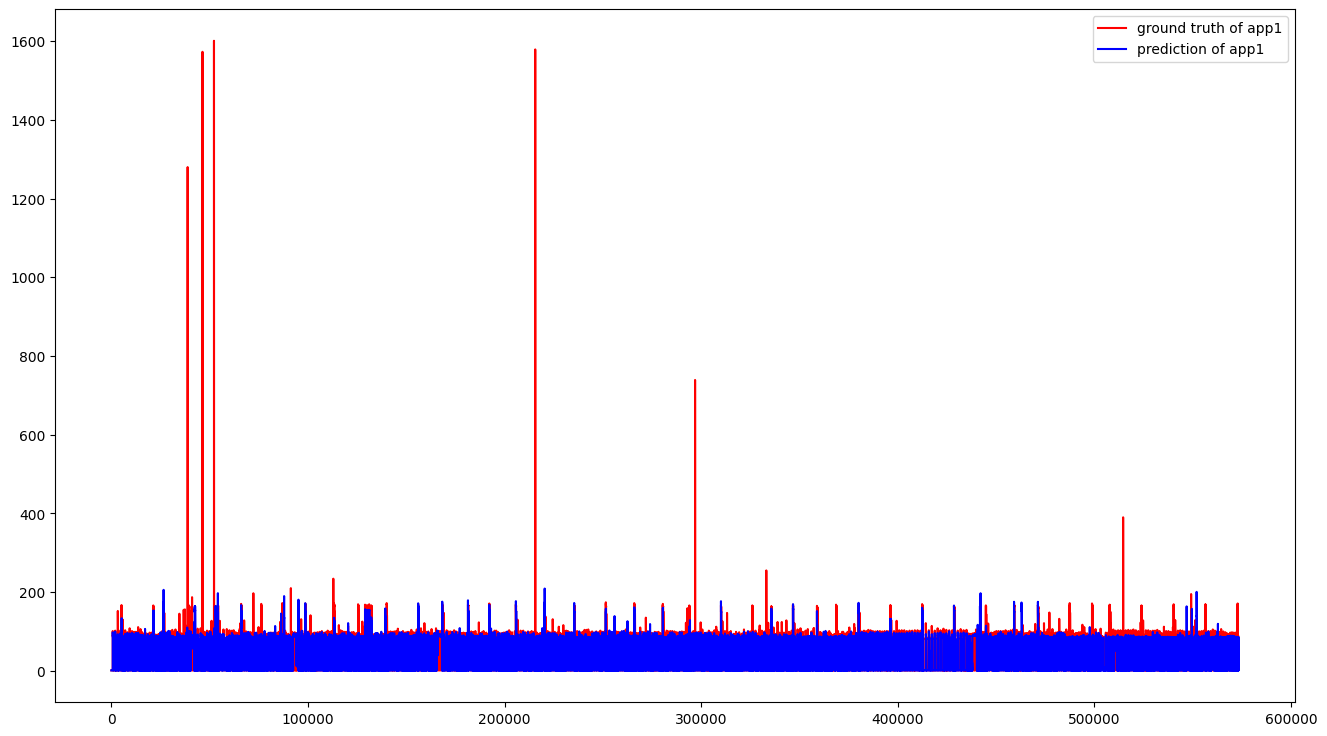

f1_energy_base: [0.76506627]
mae: [16.74727937]
ane: 0.005088730295629131


In [18]:
tester(save_dir = model_save_dir1, app_num = 1)

In [19]:
trainer(epochs = 20, save_dir = model_save_dir2, app_num = 2, lr = 5e-4, weight_factor = 5.0, weight_factor_off = 1.0, threshold_watt = 20.0)

100%|██████████| 4480/4480 [07:21<00:00, 10.15it/s]


EPOCH: 1, average train loss: 0.03427993119902177


100%|██████████| 560/560 [00:39<00:00, 14.35it/s]


EPOCH: 1, average eval loss: 0.03861645144643262


100%|██████████| 4480/4480 [07:33<00:00,  9.87it/s]


...

EPOCH: 19, average eval loss: 0.017362059779199107


100%|██████████| 4480/4480 [06:32<00:00, 11.41it/s]


EPOCH: 20, average train loss: 0.004771968261853284


100%|██████████| 560/560 [00:23<00:00, 23.51it/s]

EPOCH: 20, average eval loss: 0.015535873484831037
Done training model for appliance 2


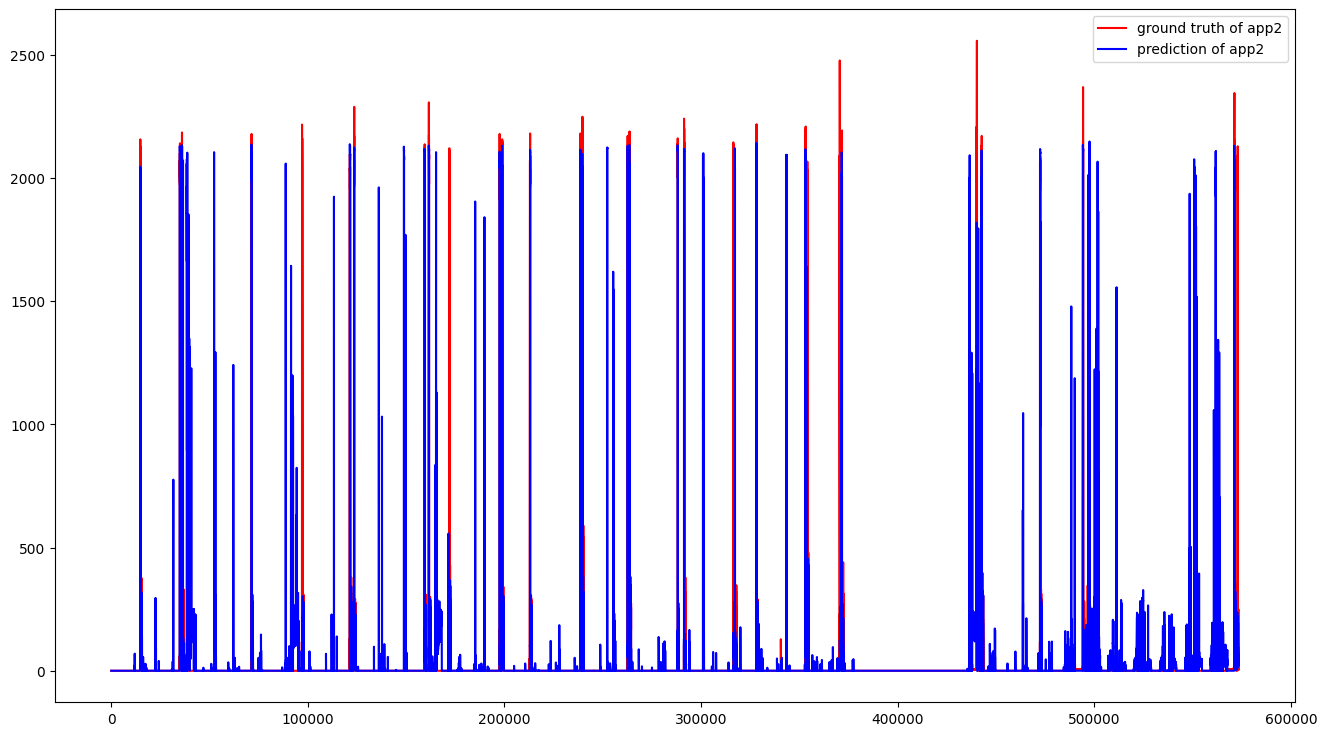

f1_energy_base: [0.59793959]
mae: [19.29041292]
ane: 0.35578327920268277


In [20]:
tester(save_dir = model_save_dir2, app_num = 2)

In [17]:
trainer(epochs = 20, save_dir = model_save_dir3, app_num = 3, lr = 5e-4, weight_factor = 3.0, weight_factor_off = 1.0, threshold_watt = 10.0)

100%|██████████| 4480/4480 [09:01<00:00,  8.28it/s]


EPOCH: 1, average train loss: 0.034675054409516244


100%|██████████| 560/560 [00:44<00:00, 12.53it/s]


EPOCH: 1, average eval loss: 0.03285313506411122


100%|██████████| 4480/4480 [07:22<00:00, 10.13it/s]


...

EPOCH: 14, average train loss: 0.013343281414043824


100%|██████████| 560/560 [00:34<00:00, 16.30it/s]


EPOCH: 14, average eval loss: 0.02528679568453559


  4%|▍         | 181/4480 [00:15<06:06, 11.74it/s]


KeyboardInterrupt: 

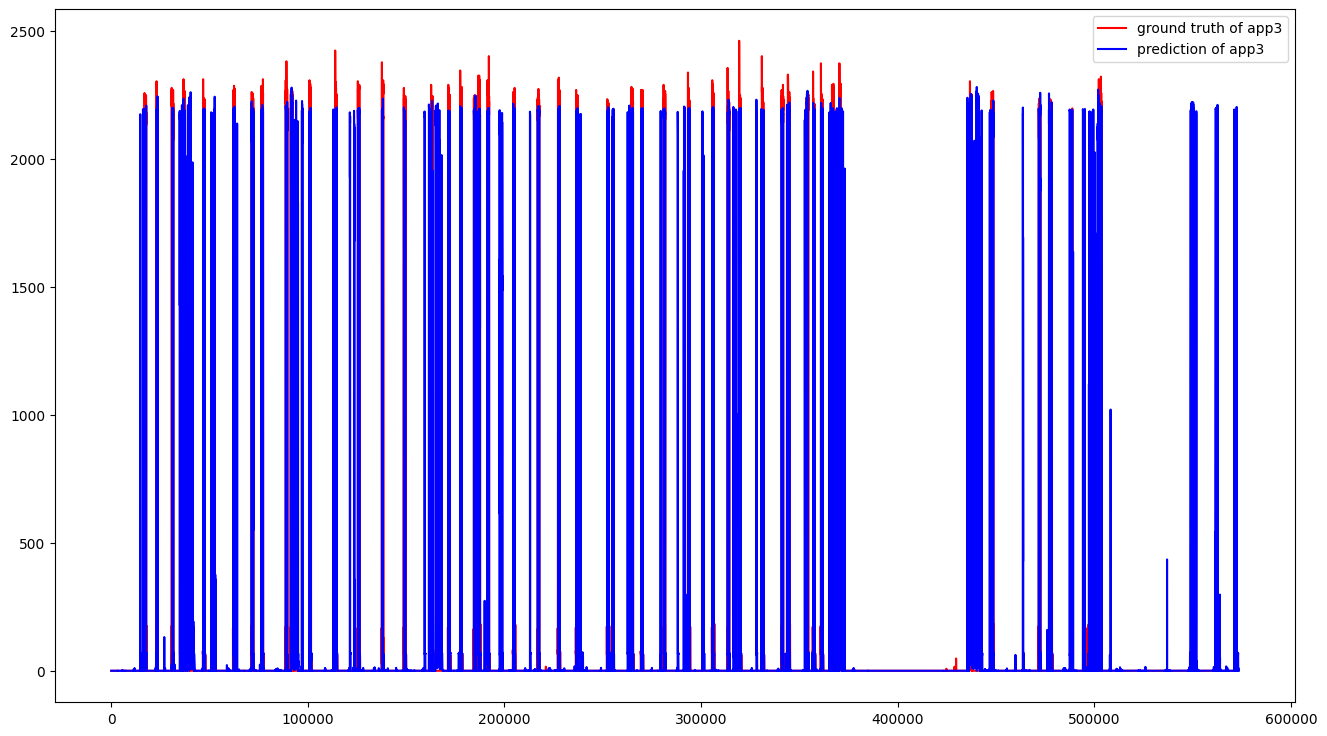

f1_energy_base: [0.67803606]
mae: [52.17433296]
ane: 0.3623529165526887


([0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,

In [18]:
tester(save_dir =  model_save_dir3, app_num = 3) # sau chuẩn hóa và weighted loss

In [20]:
trainer(epochs = 20, save_dir = model_save_dir5, app_num = 5, lr = 5e-4, weight_factor = 10.0, weight_factor_off = 1.0, threshold_watt = 20.0)

100%|██████████| 4480/4480 [07:40<00:00,  9.73it/s]


EPOCH: 1, average train loss: 0.02146611678548912


100%|██████████| 560/560 [00:39<00:00, 14.29it/s]


EPOCH: 1, average eval loss: 0.0285741757354117


100%|██████████| 4480/4480 [07:36<00:00,  9.81it/s]


...

EPOCH: 19, average train loss: 0.009140030648063657


100%|██████████| 560/560 [00:24<00:00, 22.98it/s]


EPOCH: 19, average eval loss: 0.010750660219231836


  2%|▏         | 70/4480 [00:06<06:32, 11.23it/s]


KeyboardInterrupt: 

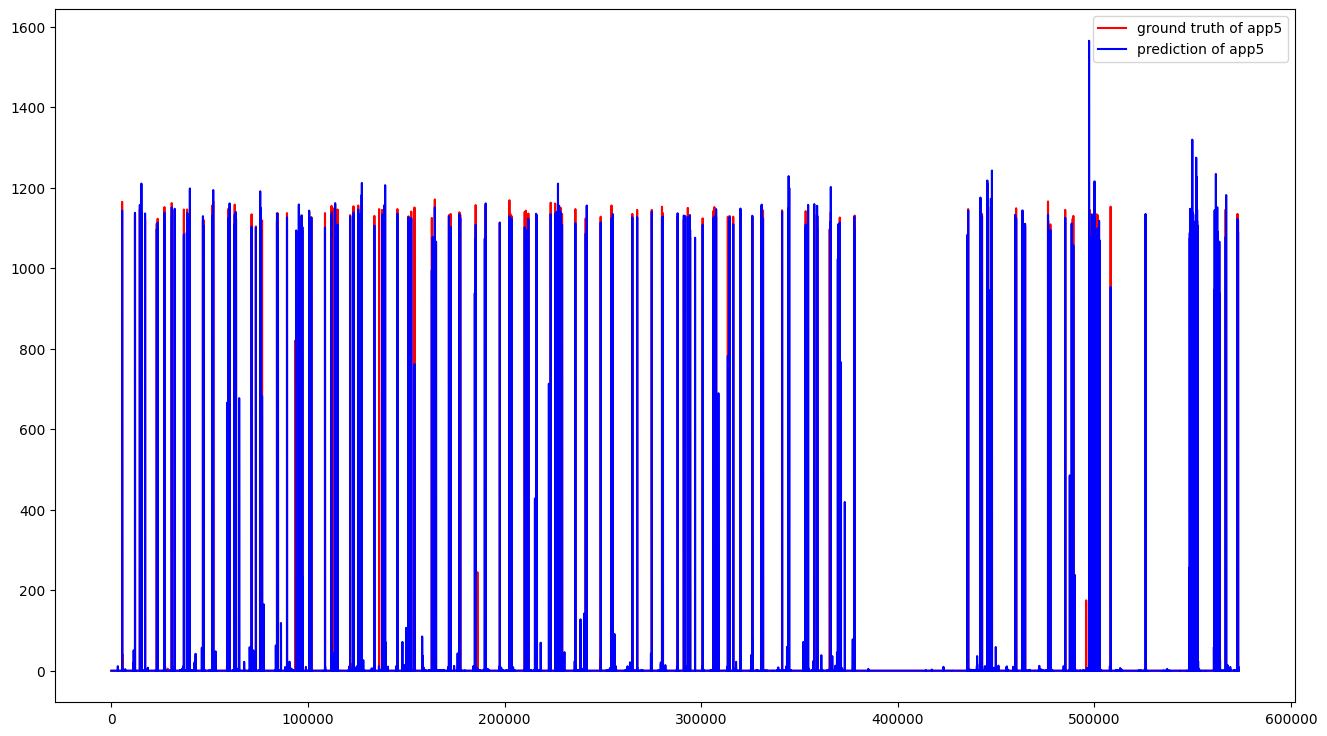

f1_energy_base: [0.60877315]
mae: [3.4237953]
ane: 0.3254113389975992


([0.12564104795455933,
  0.12519223988056183,
  0.12499328702688217,
  0.12612223625183105,
  0.12311017513275146,
  0.12481746822595596,
  0.12495627254247665,
  0.1257891058921814,
  0.12513208389282227,
  0.12387359887361526,
  0.1257058084011078,
  0.12586313486099243,
  0.12307778745889664,
  0.12481746822595596,
  0.12586313486099243,
  0.12514597177505493,
  0.12498403340578079,
  0.1250303089618683,
  0.1250303089618683,
  0.125025674700737,
  0.125025674700737,
  0.125025674700737,
  0.12612223625183105,
  0.12310092151165009,
  0.12480821460485458,
  0.12495164573192596,
  0.12485910952091217,
  0.12577983736991882,
  0.12513671815395355,
  0.12386897206306458,
  0.1245306059718132,
  0.12491000443696976,
  0.12486373633146286,
  0.12485910952091217,
  0.12485910952091217,
  0.12486373633146286,
  0.1257891058921814,
  0.12514597177505493,
  0.12499328702688217,
  0.12503954768180847,
  0.12392912060022354,
  0.12453985959291458,
  0.12491000443696976,
  0.12579834461212158,


In [21]:
tester(save_dir = model_save_dir5, app_num = 5)

# Chú ý

Ở 1 số thiết bị kết quả predict rất tệ có thể nguyên do là tôi đã chuẩn hóa mỗi data mà không chuẩn hóa target gây ra mất cân bằng gradient, ngoài ra đối với các thiết bị như lò vi sóng thời gian off rất nhiều nên nếu dùng hàm loss mae hoặc mse thì model cứ đoán là 0 để an toàn nên có thể sẽ cần đổi hàm loss

Đối với 1 số thiết bị trong có vẻ hội tụ ngay từ các epoch đầu là vì giá trị khởi tạo ban đầu của các trọng số trong pytorch là bé cộng thêm việc chuẩn hóa input đầu vào theo z score nên đầu ra sẽ rất bé, trùng khớp với các thiết bị thường có thời gian OFF là nhiều thành ra model nghĩ là nó đã đúng và lười đi thêm 

In [16]:
trainer(epochs = 20, save_dir = model_save_dir8, app_num = 8, lr = 5e-4, weight_factor = 10.0, weight_factor_off = 1.0, threshold_watt = 2000.0)

100%|██████████| 4480/4480 [11:08<00:00,  6.70it/s]


EPOCH: 1, average train loss: 0.0529880724413098


100%|██████████| 560/560 [00:43<00:00, 12.94it/s]


EPOCH: 1, average eval loss: 0.004957425278137505


100%|██████████| 4480/4480 [08:13<00:00,  9.08it/s]


...

EPOCH: 10, average train loss: 0.004508099428915102


100%|██████████| 560/560 [00:24<00:00, 22.79it/s]


EPOCH: 10, average eval loss: 0.0041959977233480975


 33%|███▎      | 1498/4480 [01:59<03:58, 12.49it/s]


KeyboardInterrupt: 

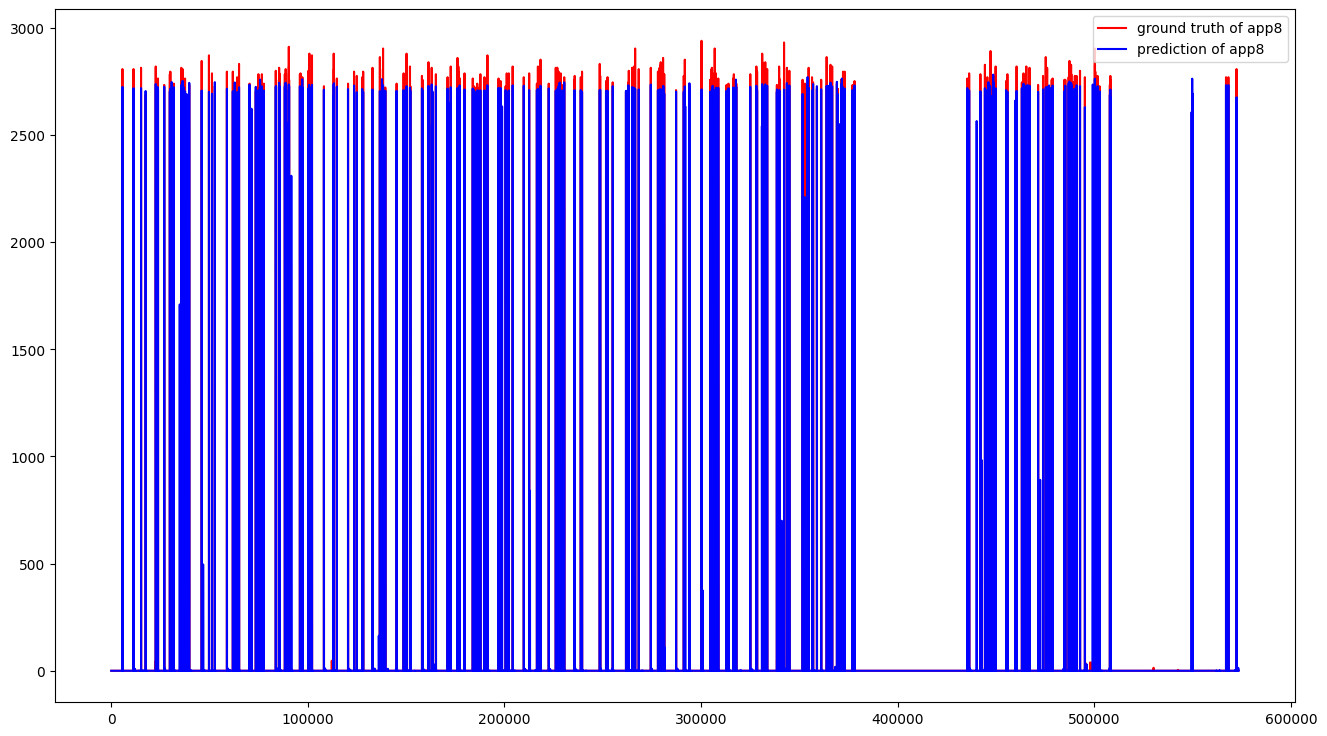

f1_energy_base: [0.88836451]
mae: [4.62987497]
ane: 0.12744642370682932


([0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,

In [17]:
tester(save_dir = model_save_dir8, app_num = 8)